In [3]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import xesmf as xe
from pathlib import Path 

In [4]:
### from Maria Molina 2025

def edges_from_centers(c, clip=None):
    c = np.asarray(c); d = np.diff(c)
    e = np.concatenate(([c[0]-d[0]/2], (c[:-1]+c[1:])/2, [c[-1]+d[0]/2]))
    return np.clip(e, *clip) if clip is not None else e

def standardize_ds(ds_in):
    ds_in = ds_in.rename(latitude="lat", longitude="lon")
    ds_in = ds_in.assign_coords(lon=(ds_in.lon % 360)).sortby("lon").sortby("lat")
    return ds_in

def build_regridder_with_poles(ds_in, dlat=1, method="conservative_normed", filename=None, reuse=False):
   # ds = standardize_ds(ds_in) 

    # --- source grid + clipped bounds (avoid ±90±Δ/2) ---
    lat_in, lon_in = ds_in.lat.values, ds_in.lon.values
    src = xr.Dataset(coords=dict(
        lat=("lat", lat_in), lon=("lon", lon_in),
        lat_b=("lat_b", edges_from_centers(lat_in, clip=(-90, 90))),
        lon_b=("lon_b", edges_from_centers(lon_in, clip=(0, 360)))
    ))

    # --- destination grid: 240 x 121 (includes poles) ---
    lat_out = np.linspace(-90, 90, int(round(180/dlat))+1)   # 121
    lon_out = np.arange(0, 360, dlat)                        # 240
    dst = xr.Dataset(coords=dict(
        lat=("lat", lat_out), lon=("lon", lon_out),
        lat_b=("lat_b", edges_from_centers(lat_out, clip=(-90, 90))),
        lon_b=("lon_b", edges_from_centers(lon_out, clip=(0, 360)))
    ))

    R = xe.Regridder(src, dst, method,
                     periodic=True, filename=filename,
                     reuse_weights=reuse, ignore_degenerate=True)
    return R

In [3]:
nominal_res = 5.0
overwrite_regridder = True 

ds = xr.open_dataset('/glade/derecho/scratch/molina/AIMIP/ERA5-0.25deg-monthly-mean-forcing-1978-2024.nc')
ds = standardize_ds(ds).load()
ds.to_netcdf(f"/glade/work/khall/ERA5/prod/AIMIP-Forcings_original_native0p25x0p25.nc")

for var in ['sea_surface_temperature', 'sea_ice_cover', 'land_sea_mask'  ]:

    da = ds[var]
    if var != 'land_sea_mask':
        mask = xr.where(~np.isnan(da.isel(time=0, drop=True)), 1, 0)
    else:
        mask = xr.where(~np.isnan(da), 1, 0)

    da = da.to_dataset() 
    
    regridding_weights = f"/glade/work/khall/ERA5/dev/aimip_forcing_conservative_normed_regridder_with_poles_{var}_res{nominal_res}.nc"
    da['mask'] = mask
    regridder = build_regridder_with_poles(
        da,
        dlat=nominal_res, 
        method="bilinear",
        filename=None,
        reuse=False
    )


    regridded_ds = regridder(da)

    out_filename = f"/glade/work/khall/ERA5/prod/AIMIP-Forcings_{var.upper()}_197810-202412_bilinear_{str(nominal_res).replace('.','p')}x{str(nominal_res).replace('.','p')}.nc"
    regridded_ds.to_netcdf(out_filename)




/glade/work/khall/conda-envs/torch/lib/python3.12/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/glade/work/khall/conda-envs/torch/lib/python3.12/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


opened nominal res
opened orig


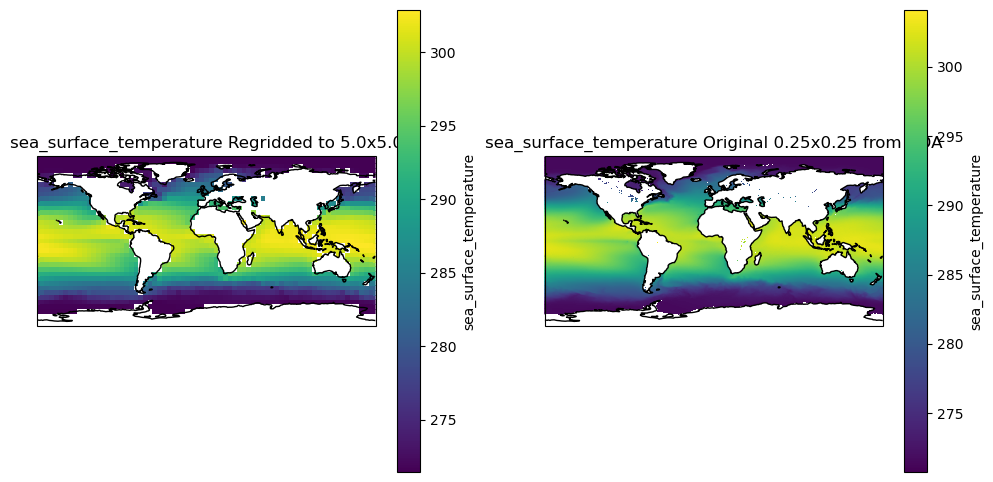

         Nominal      Original
means:  286.62766 286.88214
mins:  271.09265 269.2553
maxs:  307.74738 309.51132
stddevs:  11.674672 11.640167
opened nominal res
opened orig


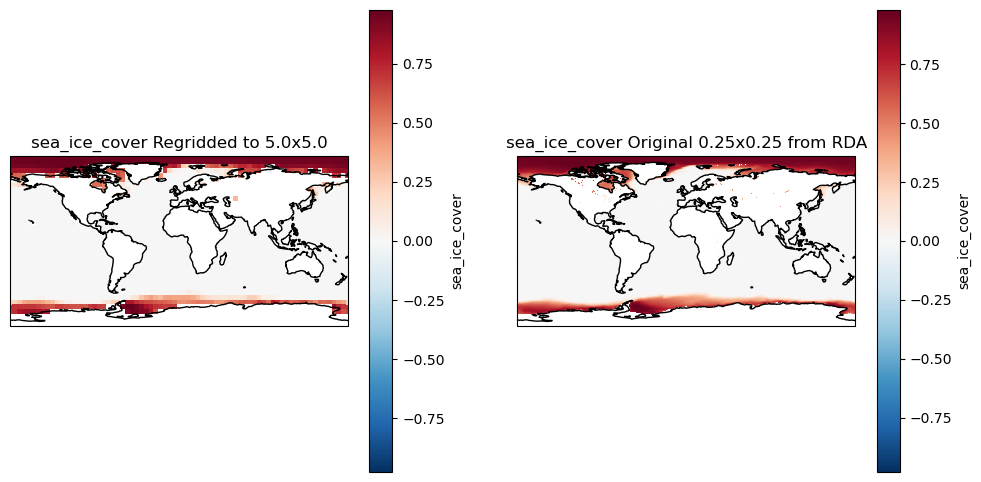

         Nominal      Original
means:  0.17930186 0.1669475
mins:  -1.9542505e-09 -1.9542505e-09
maxs:  1.0 1.0
stddevs:  0.36107016 0.34935358
opened nominal res
opened orig


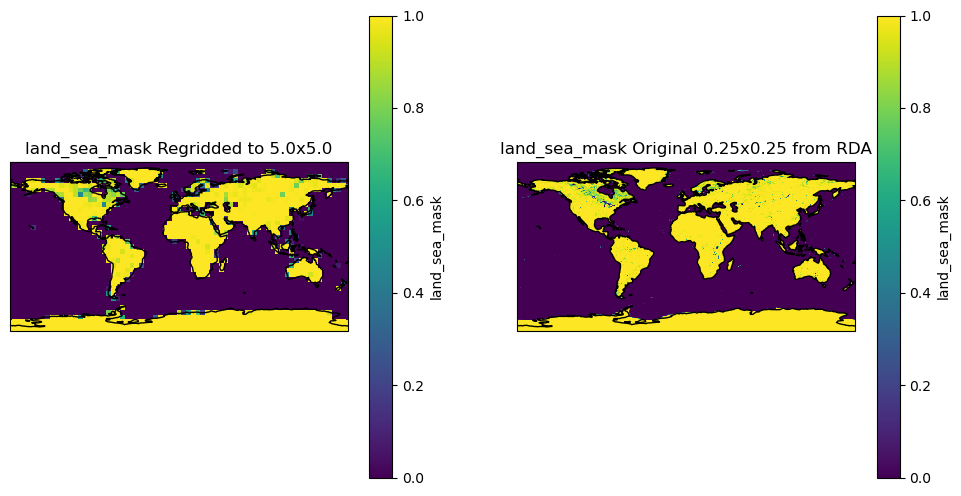

         Nominal      Original
means:  0.3410314 0.33589727
mins:  0.0 0.0
maxs:  1.0 1.0
stddevs:  0.4620094 0.460536


In [4]:
import cartopy.crs as ccrs 
import matplotlib.pyplot as plt 
nominal_res = 5.0

for var in ['sea_surface_temperature', 'sea_ice_cover', 'land_sea_mask'  ]:
    fig, ax = plt.subplots(nrows=1, ncols=2, subplot_kw={'projection': ccrs.PlateCarree()} , figsize=(12, 6))
    ds_res = xr.open_dataset(f"/glade/work/khall/ERA5/prod/AIMIP-Forcings_{var.upper()}_197810-202412_bilinear_{str(nominal_res).replace('.','p')}x{str(nominal_res).replace('.','p')}.nc") 
    print('opened nominal res')

    ds_orig = xr.open_dataset(f"/glade/work/khall/ERA5/prod/AIMIP-Forcings_original_native0p25x0p25.nc") 
    print('opened orig')

    if var != 'land_sea_mask':
        ds_res[var].mean('time').plot(ax=ax[0])
    else:
        ds_res[var].plot(ax=ax[0])

    ax[0].coastlines()
    ax[0].set_title(f"{var} Regridded to {nominal_res}x{nominal_res}")

    if var != 'land_sea_mask':
        ds_orig[var].mean('time').plot(ax=ax[1])
    else:
        ds_orig[var].plot(ax=ax[1])

    ax[1].coastlines()
    ax[1].set_title(f"{var} Original 0.25x0.25 from RDA")
    plt.show()

    print("         Nominal      Original")
    print("means: ", ds_res[var].mean().values, ds_orig[var].mean().values) 
    print("mins: ", ds_res[var].min().values, ds_orig[var].min().values) 
    print("maxs: ", ds_res[var].max().values, ds_orig[var].max().values) 
    print("stddevs: ", ds_res[var].std().values, ds_orig[var].std().values) 


# Regrid Invariant RDA ERA5 Files

In [ ]:
import xarray as xr 
overwrite_regridder  = True
invariant_variables = {
    'sdor': "e5.oper.invariant.128_160_sdor.ll025sc.1979010100_1979010100.nc",
    'anor': "e5.oper.invariant.128_162_anor.ll025sc.1979010100_1979010100.nc",
    'isor': "e5.oper.invariant.128_161_isor.ll025sc.1979010100_1979010100.nc",
    'slor': "e5.oper.invariant.128_163_slor.ll025sc.1979010100_1979010100.nc",
    'lsm': "e5.oper.invariant.128_172_lsm.ll025sc.1979010100_1979010100.nc"
}
nominal_res = 1.5

for var in invariant_variables.keys():
    ds = xr.open_dataset(f'/glade/campaign/collections/rda/data/d633000/e5.oper.invariant/197901/{invariant_variables[var]}').mean('time')
    ds = standardize_ds(ds).load()

    mask = xr.where(~np.isnan(ds[var.upper()]), 1, 0)
    ds['mask'] = mask

    regridding_weights = f"/glade/work/khall/ERA5/dev/conservative_normed_regridder_with_poles_{var}_res{nominal_res}.nc"
    regridder = build_regridder_with_poles(
        ds, 
        dlat=nominal_res, 
        method="conservative_normed", 
        filename=None if (not Path(regridding_weights).is_file()) or overwrite_regridder else regridding_weights,
        reuse= Path(regridding_weights).is_file() and not overwrite_regridder
    )
    if not Path(regridding_weights).is_file() or overwrite_regridder:
        regridder.to_netcdf(regridding_weights)

    regridded_ds = regridder(ds)
    print(regridded_ds)

    out_filename = f"/glade/work/khall/ERA5/prod/ERA5_{var.upper()}_195001-202212_{str(nominal_res).replace('.','p')}x{str(nominal_res).replace('.','p')}.nc"
    regridded_ds.to_netcdf(out_filename)
    print(var + '    file saved to ' + out_filename)

<xarray.Dataset> Size: 351kB
Dimensions:  (lat: 121, lon: 240)
Coordinates:
  * lat      (lat) float64 968B -90.0 -88.5 -87.0 -85.5 ... 85.5 87.0 88.5 90.0
  * lon      (lon) float64 2kB 0.0 1.5 3.0 4.5 6.0 ... 354.0 355.5 357.0 358.5
Data variables:
    SDOR     (lat, lon) float32 116kB 3.03 3.044 3.069 3.119 ... 0.0 0.0 0.0 0.0
    mask     (lat, lon) int64 232kB 1 1 0 0 1 0 0 1 0 1 ... 0 1 1 1 0 0 1 0 1 1
Attributes:
    regrid_method:  conservative_normed
sdor    file saved to /glade/work/khall/ERA5/prod/ERA5_SDOR_195001-202212_1p5x1p5.nc
<xarray.Dataset> Size: 351kB
Dimensions:  (lat: 121, lon: 240)
Coordinates:
  * lat      (lat) float64 968B -90.0 -88.5 -87.0 -85.5 ... 85.5 87.0 88.5 90.0
  * lon      (lon) float64 2kB 0.0 1.5 3.0 4.5 6.0 ... 354.0 355.5 357.0 358.5
Data variables:
    ANOR     (lat, lon) float32 116kB -0.9513 -0.915 -0.8421 ... 0.7854 0.7854
    mask     (lat, lon) int64 232kB 1 1 0 0 1 0 0 1 0 1 ... 0 1 1 1 0 0 1 0 1 1
Attributes:
    regrid_method:  conservat